In [1]:
import sys
print(sys.executable)

c:\Users\Francisco\Documents\Documentos-secundario\Visual-Studio-Code-Repository\CT5108_Capstone\Unified_forecasting\.venv\Scripts\python.exe


### Libraries


In [2]:
import importlib.util
import sys
import itertools
from termcolor import colored

required = {
    "numpy": "numpy>=1.24",
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
    "sklearn": "scikit-learn",
    "torch": "torch>=2.1",
    "tqdm": "tqdm>=4.65",
}

missing = [package for module, package in required.items() if importlib.util.find_spec(module) is None]

if missing:
    print("Missing packages:", ", ".join(missing))
else:
    print("Environment ready")


Environment ready


In [3]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import RobustScaler
from tqdm.auto import tqdm

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from models.DLinearFutureCovariates import DLinearFutureCovariates

print(DLinearFutureCovariates)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


<class 'models.DLinearFutureCovariates.DLinearFutureCovariates'>


c:\Users\Francisco\Documents\Documentos-secundario\Visual-Studio-Code-Repository\CT5108_Capstone\Unified_forecasting\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device(type='cpu')

# DLinear with past and future numerical covariates




Model input:

- past sales
- past covariates from the input window
- known covariates for every day in the forecast horizon


In [4]:
FEATURE_PATH = PROJECT_ROOT / "data/m5/processed/m5_long_features.parquet"
COMBINED_SPLIT_PATH = PROJECT_ROOT / "data/m5/processed/splits/combined_exclusive_series.csv"


### Prepare the grid of hyperparameters and scenarios


In [5]:
PRED_LEN = 28
BATCH_SIZE = 64
RANDOM_SEED = 42

# 0 means use all available series.
MAX_TRAIN_SERIES_PER_GROUP = 0
MAX_EVAL_SERIES_PER_GROUP = 0
EARLY_STOPPING_MIN_DELTA = 1e-5

# True if prices are available on the future covariates
ASSUME_FUTURE_PRICES_KNOWN = True

GRID = {
    "seq_len": [28, 56, 112],
    "learning_rate": [1e-3, 3e-4],
    "epochs": [50],
    "samples_per_epoch": [10_000, 20_000, 40_000],
}

TRAIN_GROUPS = ["normal", "intermittent"]
EVAL_GROUPS = ["normal", "intermittent", "cold_start_item", "cold_start_store", "all_combined"]

MODEL_NAME = "global_dlinear_future_covariates"

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


In [6]:
TARGET_COLUMN = "log_sales"

# Historical covariates
PAST_COVARIATE_COLUMNS = [
    "day_of_week",
    "is_weekend",
    "event_flag",
    "snap_flag",
    "sell_price",
    #"price_change_pct",
]

# Forecast horizon covatiates
FUTURE_KNOWN_COVARIATE_COLUMNS = [
    "day_of_week",
    "is_weekend",
    "event_flag",
    "snap_flag",
]

if ASSUME_FUTURE_PRICES_KNOWN:
    FUTURE_KNOWN_COVARIATE_COLUMNS += [
        "sell_price",
        #"price_change_pct",
    ]

# Get index of relevant columns
ALL_COVARIATE_COLUMNS = list(dict.fromkeys(
    PAST_COVARIATE_COLUMNS + FUTURE_KNOWN_COVARIATE_COLUMNS
))

PAST_COVARIATE_INDICES = [
    ALL_COVARIATE_COLUMNS.index(column) for column in PAST_COVARIATE_COLUMNS
]
FUTURE_COVARIATE_INDICES = [
    ALL_COVARIATE_COLUMNS.index(column) for column in FUTURE_KNOWN_COVARIATE_COLUMNS
]

N_PAST_COVARIATES = len(PAST_COVARIATE_COLUMNS)
N_FUTURE_COVARIATES = len(FUTURE_KNOWN_COVARIATE_COLUMNS)

print("Past covariates:", PAST_COVARIATE_COLUMNS)
print("Future-known covariates:", FUTURE_KNOWN_COVARIATE_COLUMNS)
print("Future prices assumed known:", ASSUME_FUTURE_PRICES_KNOWN)


Past covariates: ['day_of_week', 'is_weekend', 'event_flag', 'snap_flag', 'sell_price']
Future-known covariates: ['day_of_week', 'is_weekend', 'event_flag', 'snap_flag', 'sell_price']
Future prices assumed known: True


### Read data and prepare series


In [7]:
def sample_ids(series_ids, max_count, seed):
    # Convert the input to a normal Python list.
    series_ids = list(series_ids)

    # If max_count is 0, None, or larger than the data, use all series.
    if max_count is None or max_count <= 0 or max_count >= len(series_ids):
        return series_ids

    # Otherwise sample a fixed number of series.
    return (
        pd.Series(series_ids)
        .sample(n=max_count, random_state=seed)
        .astype(int)
        .tolist()
    )


#### Read data and set subsets


In [8]:
df_combined = pd.read_csv(COMBINED_SPLIT_PATH)

split_ids = {}

# Series ids for each exclusive evaluation subset.
for split_name in ["normal", "intermittent", "cold_start_item", "cold_start_store"]:
    ids = (
        df_combined[df_combined["exclusive_split"] == split_name]["series_idx"]
        .dropna()
        .astype(int)
        .tolist()
    )

    split_ids[split_name] = sample_ids(
        ids,
        MAX_EVAL_SERIES_PER_GROUP,
        RANDOM_SEED,
    )

# The combined scenario contains every exclusive subset.
split_ids["all_combined"] = (
    split_ids["normal"]
    + split_ids["intermittent"]
    + split_ids["cold_start_item"]
    + split_ids["cold_start_store"]
)

train_ids = []

# Train one global model using normal and intermittent series only.
# Cold-start item and store series remain unseen during training.
for group_name in TRAIN_GROUPS:
    ids = (
        df_combined[df_combined["exclusive_split"] == group_name]["series_idx"]
        .dropna()
        .astype(int)
        .tolist()
    )

    train_ids.extend(
        sample_ids(
            ids,
            MAX_TRAIN_SERIES_PER_GROUP,
            RANDOM_SEED,
        )
    )

print("Train groups:", TRAIN_GROUPS)
print("Train series:", len(train_ids))

for split_name, ids in split_ids.items():
    print(split_name, len(ids))


Train groups: ['normal', 'intermittent']
Train series: 24696
normal 7600
intermittent 17096
cold_start_item 3050
cold_start_store 2744
all_combined 30490


#### Scaling past and future covariates



In [9]:
def fit_covariate_scaler(series_ids, covariate_columns, pred_len):
    scaler_df = pd.read_parquet(
        FEATURE_PATH,
        columns=["series_idx", "time_idx"] + covariate_columns,
        filters=[("series_idx", "in", list(series_ids))],
    )

    scaler_df = scaler_df.sort_values(["series_idx", "time_idx"]).reset_index(drop=True)

    # Exclude the validation horizon observations from the data used to fit the scaler
    position_from_end = scaler_df.groupby("series_idx").cumcount(ascending=False)
    scaler_df = scaler_df[position_from_end >= pred_len]

    covariates = (
        scaler_df[covariate_columns]
        .replace([np.inf, -np.inf], 0)
        .fillna(0)
        .to_numpy(dtype=np.float32)
    )

    # scaler =  StandardScaler()
    scaler = RobustScaler()
    scaler.fit(covariates)

    return scaler

#Scaler is trained only using the training series

covariate_scaler = fit_covariate_scaler(
    train_ids,
    ALL_COVARIATE_COLUMNS,
    PRED_LEN,
)

covariate_scaler


,"with_centering with_centering: bool, default=TrueIf `True`, center the data before scaling.This will cause :meth:`transform` to raise an exception when attemptedon sparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_scaling with_scaling: bool, default=TrueIf `True`, scale the data to interquartile range.",True
,"quantile_range quantile_range: tuple (q_min, q_max), 0.0 < q_min < q_max < 100.0, default=(25.0, 75.0)Quantile range used to calculate `scale_`. By default this is equal tothe IQR, i.e., `q_min` is the first quantile and `q_max` is the thirdquantile... versionadded:: 0.18","(25.0, ...)"
,"copy copy: bool, default=TrueIf `False`, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"unit_variance unit_variance: bool, default=FalseIf `True`, scale data so that normally distributed features have avariance of 1. In general, if the difference between the x-values of`q_max` and `q_min` for a standard normal distribution is greaterthan 1, the dataset will be scaled down. If less than 1, the datasetwill be scaled up... versionadded:: 0.24",False


#### Load arrays


one past-input array and one future-covariate array per series

In [10]:
def load_series_arrays(series_ids, seq_len, pred_len, covariate_scaler):
    # Read parquet filtering columns
    read_columns = list(dict.fromkeys(
        ["series_idx", "time_idx", "sales", TARGET_COLUMN] + ALL_COVARIATE_COLUMNS
    ))

    df = pd.read_parquet(
        FEATURE_PATH,
        columns=read_columns,
        filters=[("series_idx", "in", list(series_ids))],
    )
    df = df.sort_values(["series_idx", "time_idx"]).reset_index(drop=True)

    # Lists to store one array per time series.
    past_arrays = []
    future_covariate_arrays = []
    sales_arrays = []
    clean_ids = []

    #Minimum series length validation
    minimum_length = seq_len + pred_len + pred_len

    # Create one log_sales array and one sales array for each series.
    for series_idx, group in df.groupby("series_idx", sort=True):
        group = group.sort_values("time_idx")

        log_series = group[[TARGET_COLUMN]].to_numpy(dtype=np.float32).copy()
        sales_series = group["sales"].to_numpy(dtype=np.float32).copy()

        # Dealing with null and inf values
        covariates = (
            group[ALL_COVARIATE_COLUMNS]
            .replace([np.inf, -np.inf], 0)
            .fillna(0)
            .to_numpy(dtype=np.float32)
        )
        # Scaler
        covariates = covariate_scaler.transform(covariates).astype(np.float32)

        past_covariates = covariates[:, PAST_COVARIATE_INDICES]
        future_covariates = covariates[:, FUTURE_COVARIATE_INDICES]

        # past covariates (sales + past covariates)
        past_values = np.concatenate([log_series, past_covariates], axis=1)

        if len(past_values) >= minimum_length:
            past_arrays.append(past_values)
            future_covariate_arrays.append(future_covariates)
            sales_arrays.append(sales_series)
            clean_ids.append(int(series_idx))

    return past_arrays, future_covariate_arrays, sales_arrays, clean_ids


### Windowing class for batch extraction

In [11]:
class RandomWindowDataset(Dataset):
    def __init__(self,past_arrays,future_covariate_arrays,seq_len,pred_len,samples_per_epoch,seed=42):
        self.past_arrays = past_arrays
        self.future_covariate_arrays = future_covariate_arrays
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.samples_per_epoch = samples_per_epoch
        
        self.rng = np.random.default_rng(seed)

    def __len__(self):
        return self.samples_per_epoch

    def __getitem__(self, index):
        # Choose one time series
        series_position = self.rng.integers(0, len(self.past_arrays))
        past_series = self.past_arrays[series_position]
        future_series = self.future_covariate_arrays[series_position]

        # Reserve the final pred_len observations for validation.
        validation_start = len(past_series) - self.pred_len
        max_start = validation_start - self.seq_len - self.pred_len

        # Choose one training window.
        start = self.rng.integers(0, max_start + 1)
        forecast_start = start + self.seq_len
        forecast_end = forecast_start + self.pred_len

        x_past = past_series[start:forecast_start].copy()
        x_future = future_series[forecast_start:forecast_end].copy()
        y = past_series[forecast_start:forecast_end, 0:1].copy()

        return (
            torch.from_numpy(x_past),
            torch.from_numpy(x_future),
            torch.from_numpy(y),
        )


### Validation tensors and evaluation metrics


In [12]:
def build_validation_tensors(
    past_arrays,
    future_covariate_arrays,
    sales_arrays,
    seq_len,
    pred_len,
):
    x_past_values = []
    x_future_values = []
    y_log_values = []
    y_sales_values = []

    # Build one validation example for every series.
    for past_series, future_series, sales_series in zip(
        past_arrays,
        future_covariate_arrays,
        sales_arrays,
    ):
        validation_start = len(past_series) - pred_len
        validation_end = validation_start + pred_len

        x_past = past_series[validation_start - seq_len:validation_start]
        x_future = future_series[validation_start:validation_end]
        y_log = past_series[validation_start:validation_end, 0:1]
        y_sales = sales_series[validation_start:validation_end]

        x_past_values.append(x_past)
        x_future_values.append(x_future)
        y_log_values.append(y_log)
        y_sales_values.append(y_sales)

    return (
        np.stack(x_past_values).astype(np.float32),
        np.stack(x_future_values).astype(np.float32),
        np.stack(y_log_values).astype(np.float32),
        np.stack(y_sales_values).astype(np.float32)
    )


In [13]:
def calculate_metrics(pred_sales, actual_sales, zero_tresh=0.5):
    mae = np.mean(np.abs(pred_sales - actual_sales))                                            # sum(abs(y_hat - y)) / n
    rmse = np.sqrt(np.mean((pred_sales - actual_sales) ** 2))                                   # sqrt(  sum((y_hat - y)^2) / n  )
    wape = np.sum(np.abs(pred_sales - actual_sales)) / (np.sum(np.abs(actual_sales)) + 1e-8)    #  sum(abs(y_hat - y))   /   sum(abs(y))

    actual_zero = actual_sales == 0
    predicted_zero = pred_sales < zero_tresh
    
    true_positive = np.sum(predicted_zero & actual_zero)
    false_positive = np.sum(predicted_zero & ~actual_zero)
    false_negative = np.sum(~predicted_zero & actual_zero)

    zero_precision = true_positive / (true_positive + false_positive + 1e-8)    # tp / (tp + fp)
    zero_recall = true_positive / (true_positive + false_negative + 1e-8)       # tp / (tp + fn)
    zero_f1 = (
        2 * zero_precision * zero_recall
        / (zero_precision + zero_recall + 1e-8)
    )                                                                           # 2*P*R / (P + R)
    
    
    return {
        "mae": float(mae),
        "rmse": float(rmse),
        "wape": float(wape),
        "zero_precision": float(zero_precision),
        "zero_recall": float(zero_recall),
        "zero_f1": float(zero_f1)
        
    }

### Evaluation function


In [14]:
def evaluate_model_on_subset(model, past_arrays, future_covariate_arrays, sales_arrays, seq_len, pred_len):
     # Validation data
    x_past, x_future, y_val_log, actual_sales = build_validation_tensors(
        past_arrays,
        future_covariate_arrays,
        sales_arrays,
        seq_len,
        pred_len,
    )

    # Evaluation mode
    model.eval()

    # Predict
    with torch.no_grad():
        x_past_tensor = torch.from_numpy(x_past.copy()).to(device)
        x_future_tensor = torch.from_numpy(x_future.copy()).to(device)
        pred_log = model(x_past_tensor, x_future_tensor).cpu().numpy().squeeze(-1)

    # Change log_sales prediction to sales
    pred_sales = np.expm1(pred_log)
    pred_sales = np.clip(pred_sales, 0, None)

    #Baseline 1: Last value
    last_value_forecast = np.repeat(x_past[:, -1:, 0], pred_len, axis=1)
    last_value_forecast = np.expm1(last_value_forecast)

    #Baseline 2: Repeat the previous pred_len observations
    seasonal_naive_forecast = []

    for sales_series in sales_arrays:
        validation_start = len(sales_series) - pred_len
        previous_n_days = sales_series[validation_start - pred_len:validation_start]
        seasonal_naive_forecast.append(previous_n_days)

    seasonal_naive_forecast = np.stack(seasonal_naive_forecast)

    #Baseline 3: Predict all 0
    zero_forecast = np.zeros_like(actual_sales)

    return {
        "zero": calculate_metrics(zero_forecast, actual_sales),
        "last_value": calculate_metrics(last_value_forecast, actual_sales),
        "seasonal_naive_28": calculate_metrics(seasonal_naive_forecast, actual_sales),
        MODEL_NAME: calculate_metrics(pred_sales, actual_sales)
    }


### Training and model parameters


In [15]:
def train_global_dlinear_future_covariates(
    train_past_arrays, train_future_covariate_arrays, 
    seq_len, pred_len, learning_rate, epochs, samples_per_epoch, min_delta=1e-4):
    
    # Call window generator for training batches
    train_dataset = RandomWindowDataset(
        past_arrays=train_past_arrays,
        future_covariate_arrays=train_future_covariate_arrays,
        seq_len=seq_len,
        pred_len=pred_len,
        samples_per_epoch=samples_per_epoch,
        seed=RANDOM_SEED,
    )

    #Group into batches
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
    )

    # Reset seed
    torch.manual_seed(RANDOM_SEED)

    model = DLinearFutureCovariates(
        seq_len=seq_len,
        pred_len=pred_len,
        n_past_covariates=N_PAST_COVARIATES,
        n_future_covariates=N_FUTURE_COVARIATES,
    ).to(device)

    # Adam optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    # MSE as loss function
    loss_fn = torch.nn.MSELoss()

    best_train_loss = float("inf")
    best_state = None
    best_epoch = None
    previous_train_loss = None
    training_history = []

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses = []

        for x_past, x_future, y in tqdm(
            train_loader,
            desc=f"seq={seq_len}, lr={learning_rate}, epoch={epoch}",
        ):
            x_past = x_past.to(device)
            x_future = x_future.to(device)
            y = y.to(device)
            
            optimizer.zero_grad()
            prediction = model(x_past, x_future) # Forward pass
            loss = loss_fn(prediction, y) # Training loss
            loss.backward()# Gradients backpropagation
            optimizer.step() # Update weights

            train_losses.append(loss.item())

        train_loss = float(np.mean(train_losses))

        training_history.append({
            "epoch": epoch,
            "train_mse_log": train_loss,
        })

        # Save model weights if has the best training loss
        if train_loss < best_train_loss:
            best_train_loss = train_loss
            best_epoch = epoch
            best_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }

        # Simple early stopping
        if previous_train_loss is not None:
            loss_difference = abs(previous_train_loss - train_loss)

            if loss_difference < min_delta:
                print(
                    f"Early stopping at epoch {epoch}. "
                    f"Loss difference: {loss_difference:.6f}"
                )
                break

        previous_train_loss = train_loss

     # Set model weights using the epoch with lowest loss
    model.load_state_dict(best_state)

    return model, best_epoch, best_train_loss, len(training_history), training_history


### Grid search

In [40]:
#enumerate([grid_combinations[0]])

In [27]:
%%capture
all_results = []

# List of all hyperparameters combinations
grid_combinations = list(itertools.product(
    GRID["seq_len"],
    GRID["learning_rate"],
    GRID["epochs"],
    GRID["samples_per_epoch"]
))

# Train and evaluate every grid search combination
for grid_index, (seq_len, learning_rate, epochs, samples_per_epoch) in enumerate(grid_combinations): #enumerate([grid_combinations[0]]): #enumerate(grid_combinations):
    print(colored("\n----Grid run----", "green", attrs=["bold"]))
    print("seq_len:", colored(seq_len, attrs=["bold"]))
    print("learning_rate:", colored(learning_rate, attrs=["bold"]))
    print("epochs:", colored(epochs, attrs=["bold"]))
    print("samples_per_epoch:", colored(samples_per_epoch, attrs=["bold"]))

    # Get training series
    train_past_arrays, train_future_arrays, train_sales_arrays, clean_train_ids = load_series_arrays(
        train_ids, seq_len, PRED_LEN, covariate_scaler)

    print("\nLoaded train series:", len(train_past_arrays))

    #Training phase one model for each combinations
    model, best_epoch, best_train_loss, epochs_ran, training_history = (
        train_global_dlinear_future_covariates(
            train_past_arrays=train_past_arrays,
            train_future_covariate_arrays=train_future_arrays,
            seq_len=seq_len,
            pred_len=PRED_LEN,
            learning_rate=learning_rate,
            epochs=epochs,
            samples_per_epoch=samples_per_epoch,
            min_delta=EARLY_STOPPING_MIN_DELTA,
        )
    )

    # evaluate each subset
    for subset_name in EVAL_GROUPS:
        eval_past_arrays, eval_future_arrays, eval_sales_arrays, clean_eval_ids = load_series_arrays(
            split_ids[subset_name],
            seq_len,
            PRED_LEN,
            covariate_scaler
        )

        subset_metrics = evaluate_model_on_subset(
            model=model,
            past_arrays=eval_past_arrays,
            future_covariate_arrays=eval_future_arrays,
            sales_arrays=eval_sales_arrays,
            seq_len=seq_len,
            pred_len=PRED_LEN
        )

        # One record per subset -- model (including baselines) -- grid of hyperparameters
        for model_name, metrics in subset_metrics.items():
            is_dlinear = model_name == MODEL_NAME

            # Baselines are independent of the DLinear grid, so save them once.
            if not is_dlinear and grid_index > 0:
                continue

            all_results.append({              
                "train_groups": "+".join(TRAIN_GROUPS),
                "subset": subset_name,
                "model": model_name,
                "seq_len": seq_len if is_dlinear else None,
                "pred_len": PRED_LEN,
                "learning_rate": learning_rate if is_dlinear else None,
                "early_stop_delta": EARLY_STOPPING_MIN_DELTA if is_dlinear else None,
                "epochs": epochs if is_dlinear else None,
                "epochs_ran": epochs_ran if is_dlinear else None,
                "samples_per_epoch": samples_per_epoch if is_dlinear else None,
                "batch_size": BATCH_SIZE if is_dlinear else None,
                "best_epoch": best_epoch if is_dlinear else None,
                "best_train_mse_log": best_train_loss if is_dlinear else None,
                "n_train_series": len(train_past_arrays) if is_dlinear else None,
                "n_eval_series": len(eval_past_arrays),
                "past_covariates": "+".join(PAST_COVARIATE_COLUMNS) if is_dlinear else None,
                "future_covariates": "+".join(FUTURE_KNOWN_COVARIATE_COLUMNS) if is_dlinear else None,
                "future_prices_known": ASSUME_FUTURE_PRICES_KNOWN if is_dlinear else None,
                "mae": metrics["mae"],
                "rmse": metrics["rmse"],
                "wape": metrics["wape"],
                "zero_precision": metrics["zero_precision"],
                "zero_recall": metrics["zero_recall"],
                "zero_f1": metrics["zero_f1"],
            })

    print(colored("----------------------------", "green", attrs=["bold"]))

results_df = pd.DataFrame(all_results)
results_df


In [28]:
results_df.sort_values(
    ["subset", "wape"],
    ascending=[True, True],
).reset_index(drop=True)


,train_groups,subset,model,seq_len,pred_len,learning_rate,early_stop_delta,epochs,epochs_ran,samples_per_epoch,...,n_eval_series,past_covariates,future_covariates,future_prices_known,mae,rmse,wape,zero_precision,zero_recall,zero_f1
0,normal+intermittent,all_combined,global_dlinear_future_covariates,56.0,28,0.0003,0.00001,50.0,50.0,10000.0,...,30490,day_of_week+is_weekend+event_flag+snap_flag+se...,day_of_week+is_weekend+event_flag+snap_flag+se...,True,1.000291,2.319282,0.721485,0.758923,0.759495,0.759209
1,normal+intermittent,all_combined,global_dlinear_future_covariates,28.0,28,0.0003,0.00001,50.0,50.0,10000.0,...,30490,day_of_week+is_weekend+event_flag+snap_flag+se...,day_of_week+is_weekend+event_flag+snap_flag+se...,True,1.004050,2.346900,0.724196,0.758588,0.761100,0.759842
2,normal+intermittent,all_combined,global_dlinear_future_covariates,112.0,28,0.0003,0.00001,50.0,50.0,40000.0,...,30490,day_of_week+is_weekend+event_flag+snap_flag+se...,day_of_week+is_weekend+event_flag+snap_flag+se...,True,1.005636,2.334182,0.725340,0.760283,0.753159,0.756705
3,normal+intermittent,all_combined,global_dlinear_future_covariates,112.0,28,0.0003,0.00001,50.0,50.0,20000.0,...,30490,day_of_week+is_weekend+event_flag+snap_flag+se...,day_of_week+is_weekend+event_flag+snap_flag+se...,True,1.006556,2.359547,0.726004,0.761399,0.754877,0.758124
4,normal+intermittent,all_combined,global_dlinear_future_covariates,28.0,28,0.0010,0.00001,50.0,50.0,40000.0,...,30490,day_of_week+is_weekend+event_flag+snap_flag+se...,day_of_week+is_weekend+event_flag+snap_flag+se...,True,1.008181,2.356475,0.727176,0.759498,0.753782,0.756629
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,normal+intermittent,normal,global_dlinear_future_covariates,56.0,28,0.0010,0.00001,50.0,50.0,10000.0,...,7600,day_of_week+is_weekend+event_flag+snap_flag+se...,day_of_week+is_weekend+event_flag+snap_flag+se...,True,1.882454,3.829992,0.630218,0.596024,0.396024,0.475863
101,normal+intermittent,normal,global_dlinear_future_covariates,28.0,28,0.0010,0.00001,50.0,50.0,10000.0,...,7600,day_of_week+is_weekend+event_flag+snap_flag+se...,day_of_week+is_weekend+event_flag+snap_flag+se...,True,1.886540,3.843761,0.631586,0.595498,0.406323,0.483049
102,normal+intermittent,normal,seasonal_naive_28,NaN,28,NaN,NaN,NaN,NaN,NaN,...,7600,NaN,NaN,None,2.351133,4.454990,0.787125,0.466804,0.479820,0.473222
103,normal+intermittent,normal,last_value,NaN,28,NaN,NaN,NaN,NaN,NaN,...,7600,NaN,NaN,None,2.569666,4.997246,0.860287,0.481517,0.459236,0.470113


In [29]:
best_dlinear_by_subset = (
    results_df[results_df["model"] == MODEL_NAME]
    .sort_values(["subset", "wape"])
    .groupby("subset", as_index=False)
    .first()
)

best_dlinear_by_subset


,subset,train_groups,model,seq_len,pred_len,learning_rate,early_stop_delta,epochs,epochs_ran,samples_per_epoch,...,n_eval_series,past_covariates,future_covariates,future_prices_known,mae,rmse,wape,zero_precision,zero_recall,zero_f1
0,all_combined,normal+intermittent,global_dlinear_future_covariates,56.0,28,0.0003,0.00001,50.0,50.0,10000.0,...,30490,day_of_week+is_weekend+event_flag+snap_flag+se...,day_of_week+is_weekend+event_flag+snap_flag+se...,True,1.000291,2.319282,0.721485,0.758923,0.759495,0.759209
1,cold_start_item,normal+intermittent,global_dlinear_future_covariates,56.0,28,0.0003,0.00001,50.0,50.0,10000.0,...,3050,day_of_week+is_weekend+event_flag+snap_flag+se...,day_of_week+is_weekend+event_flag+snap_flag+se...,True,1.119954,2.673991,0.711574,0.749187,0.731426,0.740200
2,cold_start_store,normal+intermittent,global_dlinear_future_covariates,56.0,28,0.0003,0.00001,50.0,50.0,10000.0,...,2744,day_of_week+is_weekend+event_flag+snap_flag+se...,day_of_week+is_weekend+event_flag+snap_flag+se...,True,1.056311,2.318633,0.715797,0.755463,0.717490,0.735987
3,intermittent,normal+intermittent,global_dlinear_future_covariates,28.0,28,0.0010,0.00001,50.0,50.0,10000.0,...,17096,day_of_week+is_weekend+event_flag+snap_flag+se...,day_of_week+is_weekend+event_flag+snap_flag+se...,True,0.591369,1.232018,0.942972,0.764398,0.878954,0.817683
4,normal,normal+intermittent,global_dlinear_future_covariates,28.0,28,0.0003,0.00001,50.0,50.0,40000.0,...,7600,day_of_week+is_weekend+event_flag+snap_flag+se...,day_of_week+is_weekend+event_flag+snap_flag+se...,True,1.823642,3.661762,0.610529,0.646265,0.309541,0.418590


## Explore results

In [30]:
scatter_df = results_df.copy()

subsets_order = [
    "normal",
    "intermittent",
    "cold_start_item",
    "cold_start_store",
    "all_combined",
]

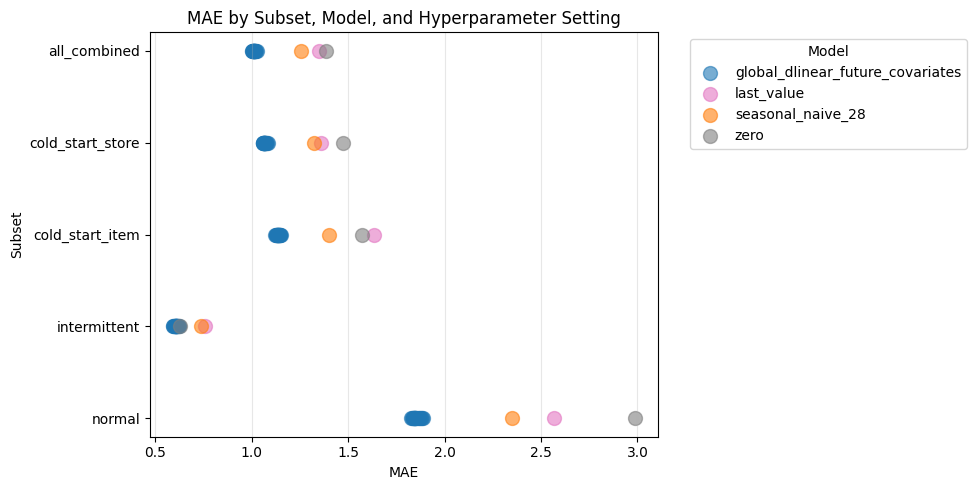

In [31]:
model_colors = {
    "zero": "tab:gray",
    "last_value": "tab:pink",
    "seasonal_naive_28": "tab:orange",
    "global_dlinear": "tab:green",
}

# Convert categorical to numeric y positions.
subset_to_y = {subset: i for i, subset in enumerate(subsets_order)}
scatter_df["subset_y"] = scatter_df["subset"].map(subset_to_y)

plt.figure(figsize=(10, 5))

# add each observation
for model_name, model_data in scatter_df.groupby("model"):
    plt.scatter(
        model_data["mae"],
        model_data["subset_y"],
        label=model_name,
        color=model_colors.get(model_name),
        alpha=0.6,
        s=100,
    )

# Set the y axis labels https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.yticks.html
plt.yticks(
    ticks=range(len(subsets_order)),
    labels=subsets_order,
)

plt.xlabel("MAE")
plt.ylabel("Subset")
plt.title("MAE by Subset, Model, and Hyperparameter Setting")
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [32]:
output_path = PROJECT_ROOT / "notebooks/Results/dlinear_covariates_v2_grid_results.csv"

results_df.to_csv(output_path, index=False)

output_path

WindowsPath('c:/Users/Francisco/Documents/Documentos-secundario/Visual-Studio-Code-Repository/CT5108_Capstone/Unified_forecasting/notebooks/Results/dlinear_covariates_v2_grid_results.csv')

### Compare with the base dlinear model

In [33]:
previous_results_path = (
    PROJECT_ROOT / "notebooks/Results/dlinear_v1_grid_results.csv"
)

if previous_results_path.exists():
    previous_results = pd.read_csv(previous_results_path)

    previous_best = (
        previous_results[previous_results["model"] == "global_dlinear"]
        .sort_values(["subset", "wape"])
        .groupby("subset", as_index=False)
        .first()[["subset", "mae", "rmse", "wape", "zero_f1"]]
        .rename(columns={
            "mae": "dlinear_mae",
            "rmse": "dlinear_rmse",
            "wape": "dlinear_wape",
            "zero_f1": "dlinear_zero_f1",
        })
    )

    future_best = best_dlinear_by_subset[
        ["subset", "mae", "rmse", "wape", "zero_f1"]
    ].rename(columns={
        "mae": "past_covariates_mae",
        "rmse": "past_covariates_rmse",
        "wape": "past_covariates_wape",
        "zero_f1": "past_covariates_zero_f1",
    })

    comparison_df = previous_best.merge(future_best, on="subset")
    comparison_df["wape_change"] = (
        comparison_df["past_covariates_wape"]
        - comparison_df["dlinear_wape"]
    )

    comparison_df
else:
    print("Previous result file not found:", previous_results_path)


In [34]:
comparison_df

,subset,dlinear_mae,dlinear_rmse,dlinear_wape,dlinear_zero_f1,past_covariates_mae,past_covariates_rmse,past_covariates_wape,past_covariates_zero_f1,wape_change
0,all_combined,1.007825,2.340267,0.726919,0.757454,1.000291,2.319282,0.721485,0.759209,-0.005434
1,cold_start_item,1.126989,2.702959,0.716044,0.738572,1.119954,2.673991,0.711574,0.740200,-0.004470
2,cold_start_store,1.061490,2.346595,0.719307,0.738157,1.056311,2.318633,0.715797,0.735987,-0.003510
3,intermittent,0.602921,1.223303,0.961393,0.815499,0.591369,1.232018,0.942972,0.817683,-0.018422
4,normal,1.843146,3.705678,0.617059,0.436294,1.823642,3.661762,0.610529,0.418590,-0.006530


In [ ]:
improvement_summary = comparison_df[["subset"]].copy()

# For error measures, a reduction is an improvement.
for metric in ["mae", "rmse", "wape"]:
    past = comparison_df[f"dlinear_{metric}"]
    future = comparison_df[f"past_covariates_{metric}"]

    improvement_summary[f"{metric}_improvement_pct"] = (
        100 * (past - future) / (past + 1e-8)
    )

# For F1, an increase is an improvement.
past_f1 = comparison_df["dlinear_zero_f1"]
future_f1 = comparison_df["past_covariates_zero_f1"]

improvement_summary["zero_f1_improvement_pct"] = (
    100 * (future_f1 - past_f1) / (past_f1 + 1e-8)
)

improvement_summary.round(2)

# 3_dlinear_future_covariates vs dlinear

,subset,mae_improvement_pct,rmse_improvement_pct,wape_improvement_pct,zero_f1_improvement_pct
0,all_combined,0.75,0.90,0.75,0.23
1,cold_start_item,0.62,1.07,0.62,0.22
2,cold_start_store,0.49,1.19,0.49,-0.29
3,intermittent,1.92,-0.71,1.92,0.27
4,normal,1.06,1.19,1.06,-4.06


### Compare with the past-covariate model

In [36]:
previous_results_path = (
    PROJECT_ROOT / "notebooks/Results/dlinear_covariates_v1_grid_results.csv"
)

if previous_results_path.exists():
    previous_results = pd.read_csv(previous_results_path)

    previous_best = (
        previous_results[previous_results["model"] == "global_dlinear"]
        .sort_values(["subset", "wape"])
        .groupby("subset", as_index=False)
        .first()[["subset", "mae", "rmse", "wape", "zero_f1"]]
        .rename(columns={
            "mae": "past_covariates_mae",
            "rmse": "past_covariates_rmse",
            "wape": "past_covariates_wape",
            "zero_f1": "past_covariates_zero_f1",
        })
    )

    future_best = best_dlinear_by_subset[
        ["subset", "mae", "rmse", "wape", "zero_f1"]
    ].rename(columns={
        "mae": "future_covariates_mae",
        "rmse": "future_covariates_rmse",
        "wape": "future_covariates_wape",
        "zero_f1": "future_covariates_zero_f1",
    })

    comparison_df = previous_best.merge(future_best, on="subset")
    comparison_df["wape_change"] = (
        comparison_df["future_covariates_wape"]
        - comparison_df["past_covariates_wape"]
    )

    comparison_df
else:
    print("Previous result file not found:", previous_results_path)


In [37]:
comparison_df

,subset,past_covariates_mae,past_covariates_rmse,past_covariates_wape,past_covariates_zero_f1,future_covariates_mae,future_covariates_rmse,future_covariates_wape,future_covariates_zero_f1,wape_change
0,all_combined,1.000452,2.315412,0.721601,0.758406,1.000291,2.319282,0.721485,0.759209,-0.000116
1,cold_start_item,1.120219,2.671217,0.711742,0.739755,1.119954,2.673991,0.711574,0.740200,-0.000168
2,cold_start_store,1.054682,2.311533,0.714693,0.735658,1.056311,2.318633,0.715797,0.735987,0.001104
3,intermittent,0.590676,1.231432,0.941867,0.818623,0.591369,1.232018,0.942972,0.817683,0.001104
4,normal,1.824089,3.663566,0.610678,0.420042,1.823642,3.661762,0.610529,0.418590,-0.000150


In [ ]:
improvement_summary = comparison_df[["subset"]].copy()

# For error measures, a reduction is an improvement.
for metric in ["mae", "rmse", "wape"]:
    past = comparison_df[f"past_covariates_{metric}"]
    future = comparison_df[f"future_covariates_{metric}"]

    improvement_summary[f"{metric}_improvement_pct"] = (
        100 * (past - future) / (past + 1e-8)
    )

# For F1, an increase is an improvement.
past_f1 = comparison_df["past_covariates_zero_f1"]
future_f1 = comparison_df["future_covariates_zero_f1"]

improvement_summary["zero_f1_improvement_pct"] = (
    100 * (future_f1 - past_f1) / (past_f1 + 1e-8)
)

improvement_summary.round(2)

# 3_dlinear_future_covariates vs 2_dlinear_covariates

,subset,mae_improvement_pct,rmse_improvement_pct,wape_improvement_pct,zero_f1_improvement_pct
0,all_combined,0.02,-0.17,0.02,0.11
1,cold_start_item,0.02,-0.10,0.02,0.06
2,cold_start_store,-0.15,-0.31,-0.15,0.04
3,intermittent,-0.12,-0.05,-0.12,-0.11
4,normal,0.02,0.05,0.02,-0.35
